In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('cleaned_campaign_data.csv')

# Fix ROI_Category as ordered category
df['ROI_Category'] = pd.Categorical(df['ROI_Category'], 
                     categories=['Low', 'Medium', 'High', 'Very High'], 
                     ordered=True)

print(f"✅ Data loaded: {df.shape}")
df.head()

✅ Data loaded: (300000, 26)


,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company,Duration_Days,CTR,CPC,CPM,Revenue,ROI_Category,Campaign_Success,Month,Day_of_Week,Quarter
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,500.0,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align,15,16.666667,1.000000,166.666667,3395.000000,Very High,1,2,Friday,1
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,500.0,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony,15,16.666667,1.000000,166.666667,4105.000000,Very High,0,5,Thursday,2
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,500.0,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit,15,16.666667,1.000000,166.666667,715.000000,Low,0,6,Sunday,2
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,500.0,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish,15,15.126484,1.706485,258.131131,954.911786,Low,0,9,Thursday,3
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,500.0,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony,15,15.126484,1.706485,258.131131,1211.414109,Medium,1,8,Wednesday,3


In [7]:
# Which channel gives best ROI, CTR, Conversion?
channel_analysis = df.groupby('Channel_Used').agg(
    Total_Campaigns = ('Campaign_ID', 'count'),
    Avg_ROI = ('ROI', 'mean'),
    Avg_CTR = ('CTR', 'mean'),
    Avg_Conversion_Rate = ('Conversion_Rate', 'mean'),
    Avg_CPC = ('CPC', 'mean'),
    Total_Revenue = ('Revenue', 'sum'),
    Avg_Engagement = ('Engagement_Score', 'mean')
).round(3).sort_values('Avg_ROI', ascending=False)

print("📊 Channel Performance:")
print(channel_analysis)

📊 Channel Performance:
              Total_Campaigns  Avg_ROI  Avg_CTR  Avg_Conversion_Rate  Avg_CPC  \
Channel_Used                                                                    
Instagram               75101    4.009   32.132                 0.08    0.387   
Twitter                 74653    4.002   32.158                 0.08    0.388   
Facebook                75164    3.987   32.136                 0.08    0.388   
Pinterest               75082    0.716   29.240                 0.08    0.660   

              Total_Revenue  Avg_Engagement  
Channel_Used                                 
Instagram      2.906949e+09           5.508  
Twitter        2.899829e+09           5.496  
Facebook       2.904407e+09           5.478  
Pinterest      1.001381e+09           1.000  


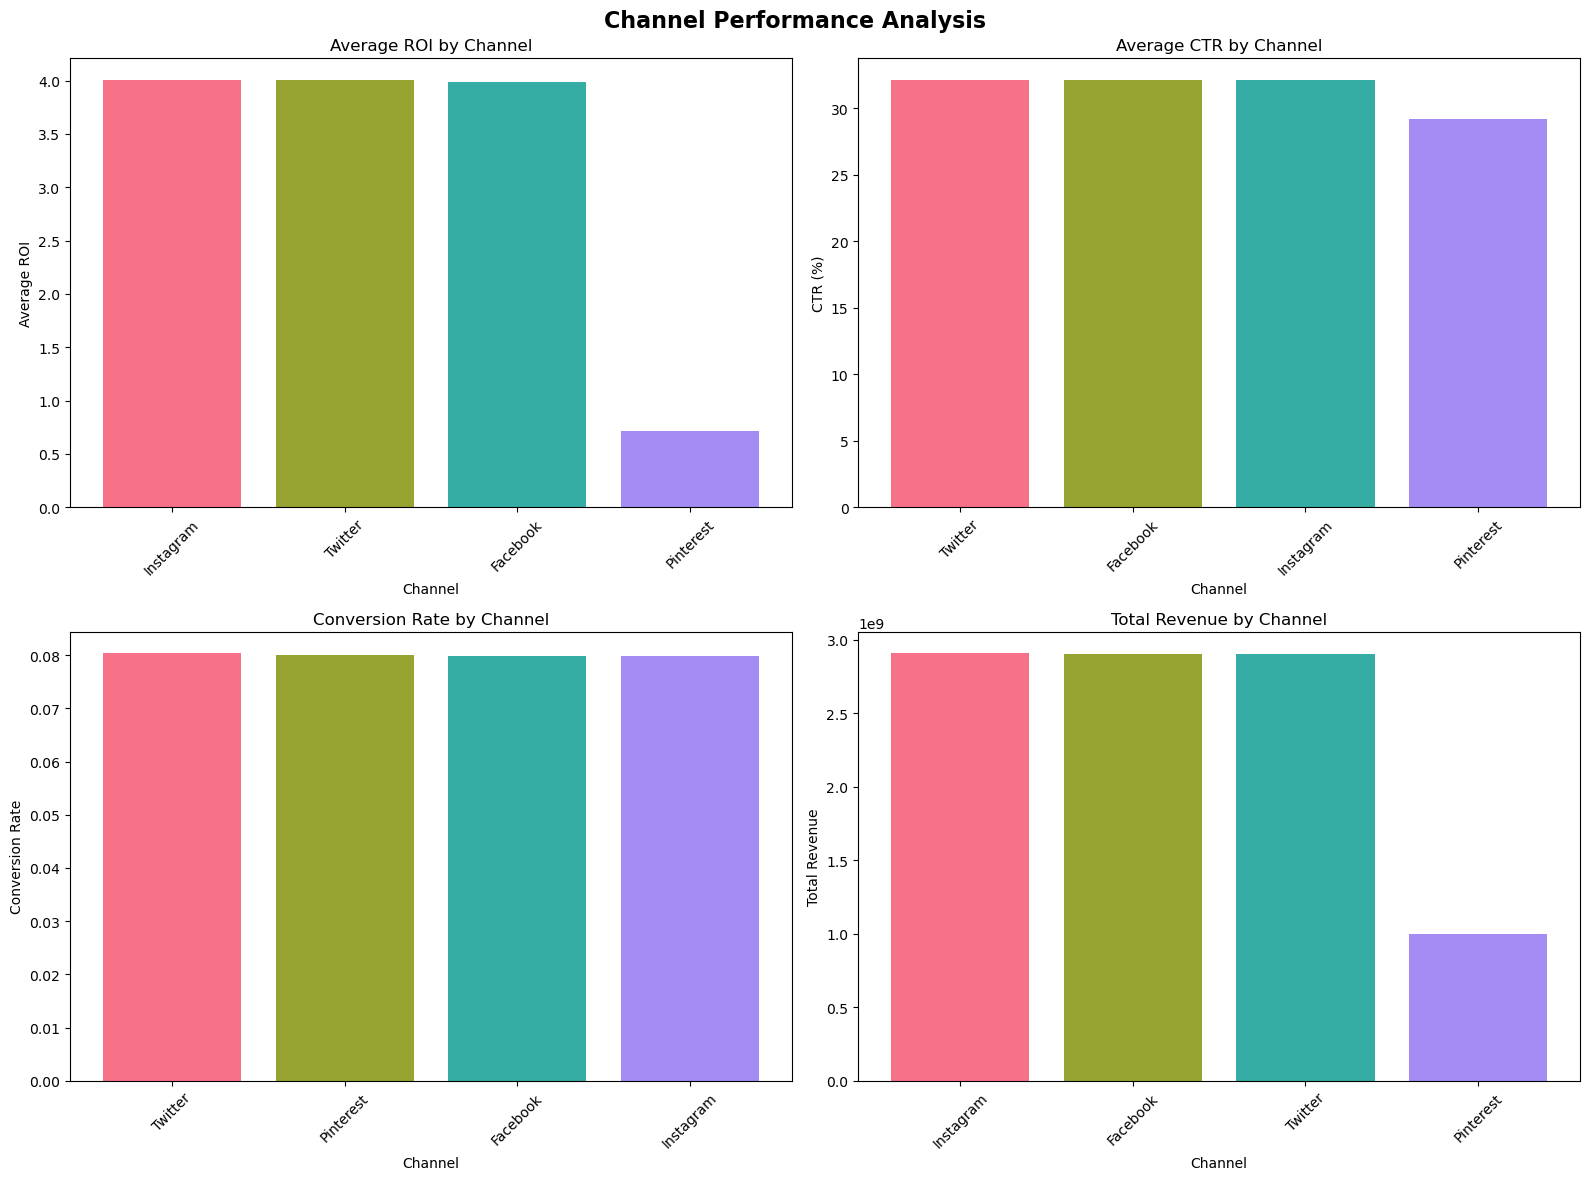

✅ Chart saved


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Channel Performance Analysis', fontsize=16, fontweight='bold')

channels = df['Channel_Used'].unique()
colors = sns.color_palette('husl', len(channels))

# Plot 1 - Avg ROI by Channel
channel_roi = df.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=False)
axes[0,0].bar(channel_roi.index, channel_roi.values, color=colors)
axes[0,0].set_title('Average ROI by Channel')
axes[0,0].set_xlabel('Channel')
axes[0,0].set_ylabel('Average ROI')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2 - Avg CTR by Channel
channel_ctr = df.groupby('Channel_Used')['CTR'].mean().sort_values(ascending=False)
axes[0,1].bar(channel_ctr.index, channel_ctr.values, color=colors)
axes[0,1].set_title('Average CTR by Channel')
axes[0,1].set_xlabel('Channel')
axes[0,1].set_ylabel('CTR (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 - Avg Conversion Rate by Channel
channel_conv = df.groupby('Channel_Used')['Conversion_Rate'].mean().sort_values(ascending=False)
axes[1,0].bar(channel_conv.index, channel_conv.values, color=colors)
axes[1,0].set_title('Conversion Rate by Channel')
axes[1,0].set_xlabel('Channel')
axes[1,0].set_ylabel('Conversion Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4 - Total Revenue by Channel
channel_rev = df.groupby('Channel_Used')['Revenue'].sum().sort_values(ascending=False)
axes[1,1].bar(channel_rev.index, channel_rev.values, color=colors)
axes[1,1].set_title('Total Revenue by Channel')
axes[1,1].set_xlabel('Channel')
axes[1,1].set_ylabel('Total Revenue')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('channel_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

In [11]:
# Target Audience Performance
audience_analysis = df.groupby('Target_Audience').agg(
    Avg_ROI = ('ROI', 'mean'),
    Avg_Conversion = ('Conversion_Rate', 'mean'),
    Avg_CTR = ('CTR', 'mean'),
    Total_Campaigns = ('Campaign_ID', 'count')
).round(3).sort_values('Avg_ROI', ascending=False)

print("👥 Audience Performance:")
print(audience_analysis)

# Customer Segment Performance
segment_analysis = df.groupby('Customer_Segment').agg(
    Avg_ROI = ('ROI', 'mean'),
    Avg_Conversion = ('Conversion_Rate', 'mean'),
    Total_Revenue = ('Revenue', 'sum')
).round(3).sort_values('Avg_ROI', ascending=False)

print("\n🎯 Customer Segment Performance:")
print(segment_analysis)

👥 Audience Performance:
                 Avg_ROI  Avg_Conversion  Avg_CTR  Total_Campaigns
Target_Audience                                                   
All Ages           3.211            0.08   31.423            33447
Men 18-24          3.195            0.08   31.434            33181
Women 45-60        3.186            0.08   31.406            33114
Women 35-44        3.178            0.08   31.417            33142
Women 25-34        3.177            0.08   31.413            33482
Men 45-60          3.169            0.08   31.420            33491
Women 18-24        3.163            0.08   31.420            33593
Men 25-34          3.160            0.08   31.406            33346
Men 35-44          3.160            0.08   31.401            33204

🎯 Customer Segment Performance:
                  Avg_ROI  Avg_Conversion  Total_Revenue
Customer_Segment                                        
Technology          3.192            0.08   1.944001e+09
Health              3.186          

🎯 Campaign Goal Performance:
                  Avg_ROI  Avg_Conversion  Avg_CTR  Success_Rate  \
Campaign_Goal                                                      
Product Launch      3.190            0.08   31.411         0.463   
Increase Sales      3.179            0.08   31.418         0.464   
Brand Awareness     3.173            0.08   31.418         0.463   
Market Expansion    3.170            0.08   31.415         0.466   

                  Total_Campaigns  
Campaign_Goal                      
Product Launch              75030  
Increase Sales              74963  
Brand Awareness             75248  
Market Expansion            74759  


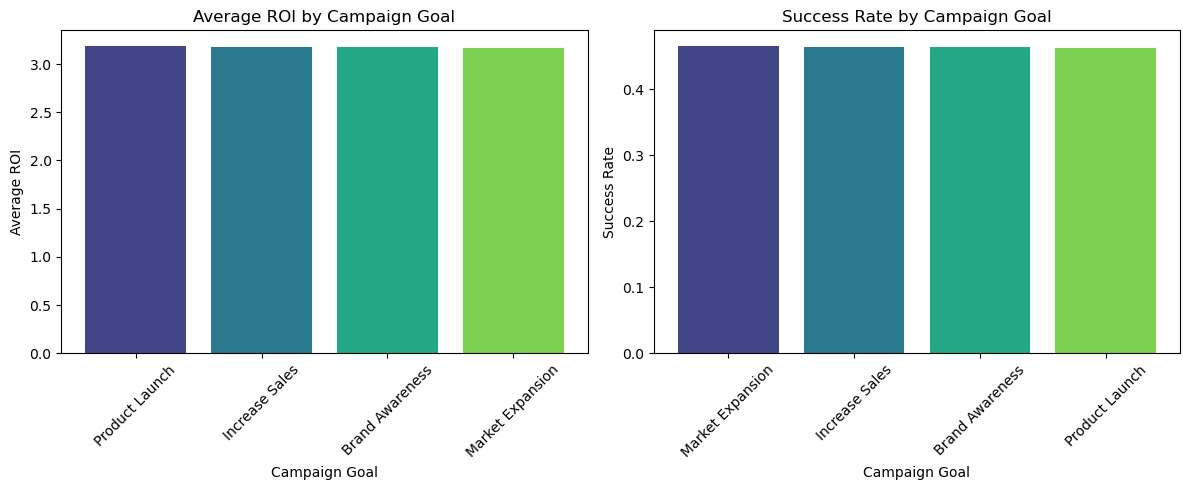

In [13]:
# Which campaign goal drives highest ROI?
goal_analysis = df.groupby('Campaign_Goal').agg(
    Avg_ROI = ('ROI', 'mean'),
    Avg_Conversion = ('Conversion_Rate', 'mean'),
    Avg_CTR = ('CTR', 'mean'),
    Success_Rate = ('Campaign_Success', 'mean'),
    Total_Campaigns = ('Campaign_ID', 'count')
).round(3).sort_values('Avg_ROI', ascending=False)

print("🎯 Campaign Goal Performance:")
print(goal_analysis)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
goal_roi = df.groupby('Campaign_Goal')['ROI'].mean().sort_values(ascending=False)
colors = sns.color_palette('viridis', len(goal_roi))
plt.bar(goal_roi.index, goal_roi.values, color=colors)
plt.title('Average ROI by Campaign Goal')
plt.xlabel('Campaign Goal')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
goal_success = df.groupby('Campaign_Goal')['Campaign_Success'].mean().sort_values(ascending=False)
plt.bar(goal_success.index, goal_success.values, color=colors)
plt.title('Success Rate by Campaign Goal')
plt.xlabel('Campaign Goal')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('campaign_goal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

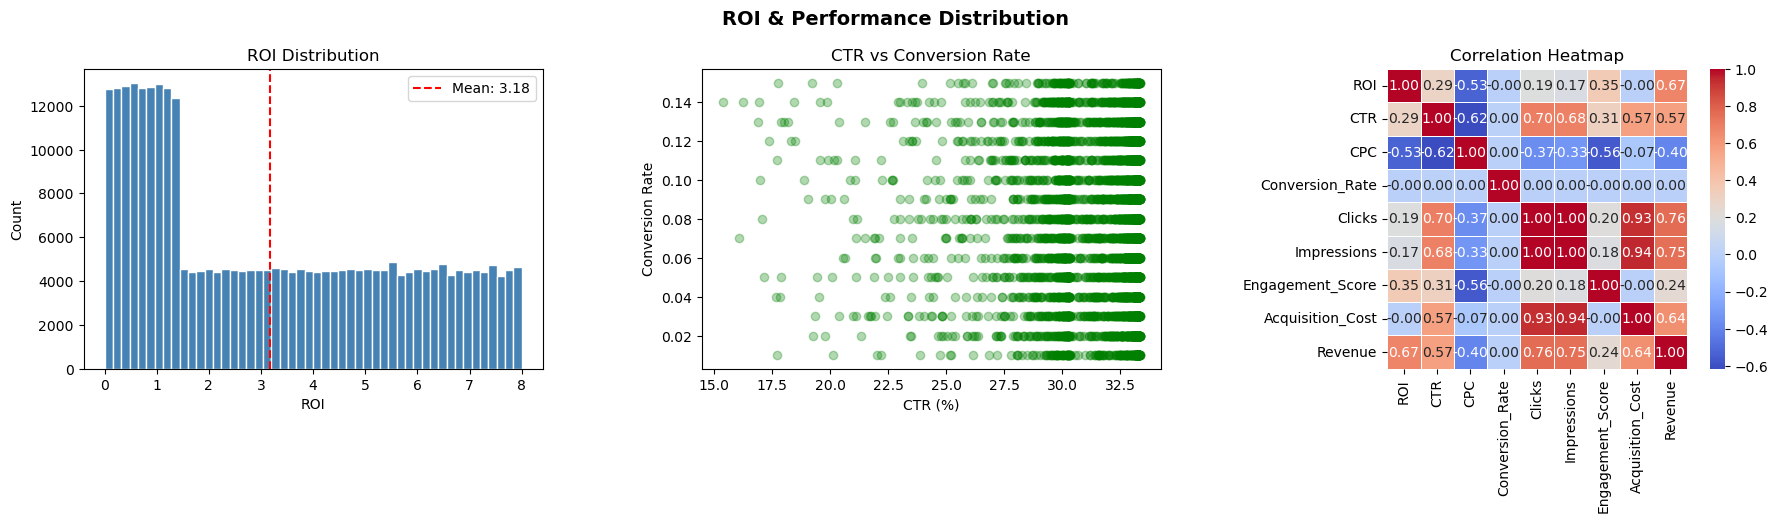

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROI & Performance Distribution', fontsize=14, fontweight='bold')

# Plot 1 - ROI Distribution
axes[0].hist(df['ROI'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('ROI Distribution')
axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Count')
axes[0].axvline(df['ROI'].mean(), color='red', 
                linestyle='--', label=f"Mean: {df['ROI'].mean():.2f}")
axes[0].legend()

# Plot 2 - CTR vs Conversion Rate
axes[1].scatter(df['CTR'].sample(5000), 
                df['Conversion_Rate'].sample(5000), 
                alpha=0.3, color='green')
axes[1].set_title('CTR vs Conversion Rate')
axes[1].set_xlabel('CTR (%)')
axes[1].set_ylabel('Conversion Rate')

# Plot 3 - Correlation Heatmap
numeric_cols = ['ROI', 'CTR', 'CPC', 'Conversion_Rate', 
                'Clicks', 'Impressions', 'Engagement_Score', 
                'Acquisition_Cost', 'Revenue']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', ax=axes[2], 
            square=True, linewidths=0.5)
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('roi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

📍 Location Performance:
             Avg_ROI  Avg_CTR  Avg_Conversion  Total_Revenue  Total_Campaigns
Location                                                                     
New York       3.190   31.427            0.08   1.940750e+09            59859
Miami          3.179   31.413            0.08   1.958226e+09            60241
Las Vegas      3.176   31.417            0.08   1.928607e+09            59729
Los Angeles    3.174   31.413            0.08   1.950831e+09            60322
Austin         3.169   31.408            0.08   1.934152e+09            59849


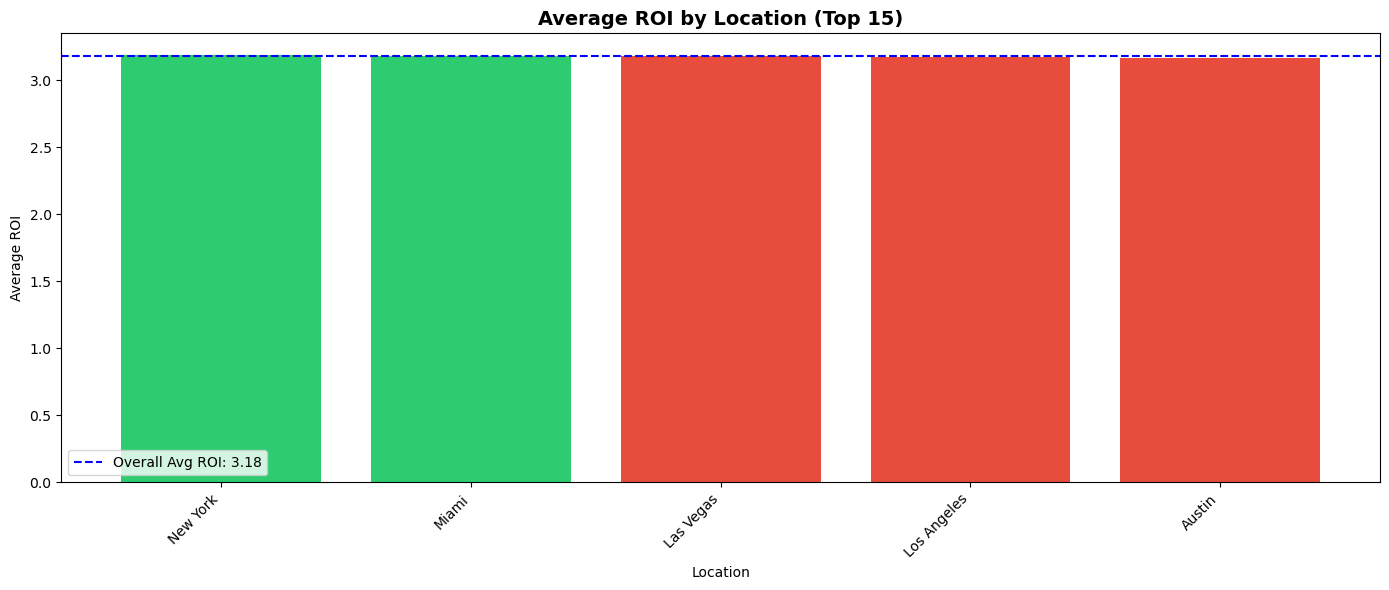

In [17]:
# Location Performance
location_analysis = df.groupby('Location').agg(
    Avg_ROI = ('ROI', 'mean'),
    Avg_CTR = ('CTR', 'mean'),
    Avg_Conversion = ('Conversion_Rate', 'mean'),
    Total_Revenue = ('Revenue', 'sum'),
    Total_Campaigns = ('Campaign_ID', 'count')
).round(3).sort_values('Avg_ROI', ascending=False)

print("📍 Location Performance:")
print(location_analysis)

# Visualize top locations
plt.figure(figsize=(14, 6))
top_locations = df.groupby('Location')['ROI'].mean().sort_values(ascending=False).head(15)
colors = ['#2ecc71' if roi > df['ROI'].mean() else '#e74c3c' 
          for roi in top_locations.values]
plt.bar(top_locations.index, top_locations.values, color=colors)
plt.axhline(df['ROI'].mean(), color='blue', 
            linestyle='--', label=f"Overall Avg ROI: {df['ROI'].mean():.2f}")
plt.title('Average ROI by Location (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Location')
plt.ylabel('Average ROI')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('location_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Monthly Performance
monthly_analysis = df.groupby('Month').agg(
    Avg_ROI = ('ROI', 'mean'),
    Avg_CTR = ('CTR', 'mean'),
    Total_Revenue = ('Revenue', 'sum'),
    Total_Campaigns = ('Campaign_ID', 'count')
).round(3)

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 
               5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
               9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_analysis.index = monthly_analysis.index.map(month_names)

print("📅 Monthly Performance:")
print(monthly_analysis)

# Day of Week Performance
dow_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_analysis = df.groupby('Day_of_Week').agg(
    Avg_ROI = ('ROI', 'mean'),
    Avg_CTR = ('CTR', 'mean'),
    Total_Campaigns = ('Campaign_ID', 'count')
).round(3).reindex(dow_order)

print("\n📅 Day of Week Performance:")
print(dow_analysis)

📅 Monthly Performance:
       Avg_ROI  Avg_CTR  Total_Revenue  Total_Campaigns
Month                                                  
Jan      3.162   31.426   8.252219e+08            25427
Feb      3.149   31.398   7.493763e+08            23317
Mar      3.190   31.435   8.362355e+08            25588
Apr      3.210   31.432   8.022642e+08            24549
May      3.179   31.405   8.155197e+08            25282
Jun      3.179   31.421   8.050709e+08            24735
Jul      3.181   31.406   8.273957e+08            25660
Aug      3.157   31.396   8.147722e+08            25375
Sep      3.184   31.424   7.993066e+08            24607
Oct      3.175   31.418   8.232484e+08            25492
Nov      3.180   31.408   7.899762e+08            24478
Dec      3.188   31.418   8.241779e+08            25490

📅 Day of Week Performance:
             Avg_ROI  Avg_CTR  Total_Campaigns
Day_of_Week                                   
Monday         3.180   31.408            42691
Tuesday        3.173   3

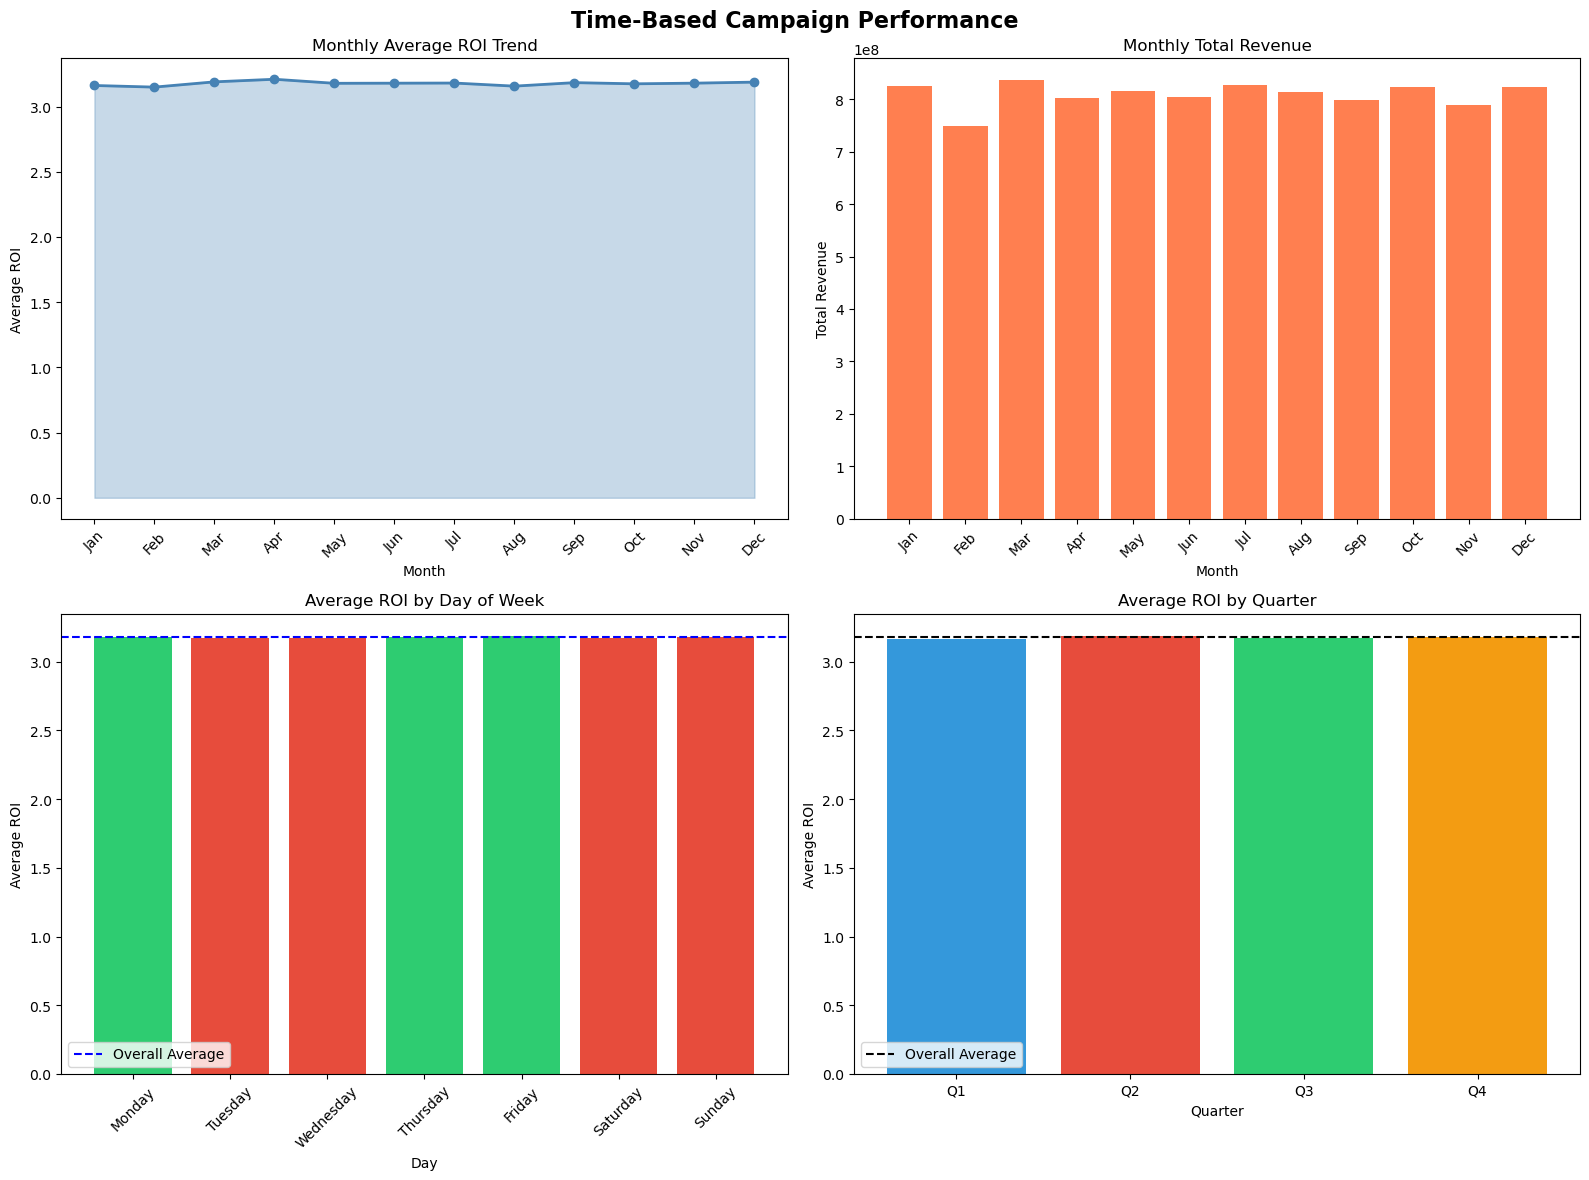

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Time-Based Campaign Performance', fontsize=16, fontweight='bold')

# Plot 1 - Monthly ROI
monthly_roi = df.groupby('Month')['ROI'].mean()
monthly_roi.index = monthly_roi.index.map(month_names)
axes[0,0].plot(monthly_roi.index, monthly_roi.values, 
               marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(range(len(monthly_roi)), 
                        monthly_roi.values, alpha=0.3, color='steelblue')
axes[0,0].set_title('Monthly Average ROI Trend')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Average ROI')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2 - Monthly Revenue
monthly_rev = df.groupby('Month')['Revenue'].sum()
monthly_rev.index = monthly_rev.index.map(month_names)
axes[0,1].bar(monthly_rev.index, monthly_rev.values, color='coral')
axes[0,1].set_title('Monthly Total Revenue')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total Revenue')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 - Day of Week ROI
dow_roi = df.groupby('Day_of_Week')['ROI'].mean().reindex(dow_order)
colors_dow = ['#2ecc71' if roi > df['ROI'].mean() 
              else '#e74c3c' for roi in dow_roi.values]
axes[1,0].bar(dow_roi.index, dow_roi.values, color=colors_dow)
axes[1,0].axhline(df['ROI'].mean(), color='blue', 
                   linestyle='--', label='Overall Average')
axes[1,0].set_title('Average ROI by Day of Week')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Average ROI')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()

# Plot 4 - Quarter Performance
quarter_perf = df.groupby('Quarter')['ROI'].mean()
quarter_perf.index = ['Q1', 'Q2', 'Q3', 'Q4']
axes[1,1].bar(quarter_perf.index, quarter_perf.values, 
              color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1,1].set_title('Average ROI by Quarter')
axes[1,1].set_xlabel('Quarter')
axes[1,1].set_ylabel('Average ROI')
axes[1,1].axhline(df['ROI'].mean(), color='black', 
                   linestyle='--', label='Overall Average')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Pinterest problem analysis
print("🔍 Pinterest vs Other Channels Deep Dive:")
print("=" * 50)

pinterest = df[df['Channel_Used'] == 'Pinterest']
others = df[df['Channel_Used'] != 'Pinterest']

metrics = ['ROI', 'CTR', 'Conversion_Rate', 
           'Engagement_Score', 'Acquisition_Cost']

for metric in metrics:
    p_val = pinterest[metric].mean()
    o_val = others[metric].mean()
    diff = ((p_val - o_val) / o_val) * 100
    print(f"{metric:20} Pinterest: {p_val:.3f} | Others: {o_val:.3f} | Diff: {diff:+.1f}%")

print("\n💡 Key Insight: Pinterest has significantly lower ROI")
print(f"   Budget wasted on Pinterest: ${pinterest['Acquisition_Cost'].sum():,.0f}")
print(f"   If reallocated to Instagram, estimated additional revenue:")
potential = (others['ROI'].mean() - pinterest['ROI'].mean()) * pinterest['Acquisition_Cost'].sum()
print(f"   ${potential:,.0f}")

🔍 Pinterest vs Other Channels Deep Dive:
ROI                  Pinterest: 0.716 | Others: 3.999 | Diff: -82.1%
CTR                  Pinterest: 29.240 | Others: 32.142 | Diff: -9.0%
Conversion_Rate      Pinterest: 0.080 | Others: 0.080 | Diff: +0.1%
Engagement_Score     Pinterest: 1.000 | Others: 5.494 | Diff: -81.8%
Acquisition_Cost     Pinterest: 7769.739 | Others: 7748.414 | Diff: +0.3%

💡 Key Insight: Pinterest has significantly lower ROI
   Budget wasted on Pinterest: $583,367,526
   If reallocated to Instagram, estimated additional revenue:
   $1,915,123,641


In [25]:
print("=" * 60)
print("📊 CAMPAIGN ANALYSIS SUMMARY")
print("=" * 60)
print(f"Total Campaigns Analyzed: {len(df):,}")
print(f"Total Revenue Generated: ${df['Revenue'].sum():,.0f}")
print(f"Total Ad Spend: ${df['Acquisition_Cost'].sum():,.0f}")
print(f"Overall Average ROI: {df['ROI'].mean():.2f}x")
print(f"Overall Average CTR: {df['CTR'].mean():.2f}%")
print(f"Overall Conversion Rate: {df['Conversion_Rate'].mean():.3f}")
print(f"\n🏆 Best Performing Channel: {df.groupby('Channel_Used')['ROI'].mean().idxmax()}")
print(f"❌ Worst Performing Channel: {df.groupby('Channel_Used')['ROI'].idxmin() if False else df.groupby('Channel_Used')['ROI'].mean().idxmin()}")
print(f"🏆 Best Campaign Goal: {df.groupby('Campaign_Goal')['ROI'].mean().idxmax()}")
print(f"🏆 Best Customer Segment: {df.groupby('Customer_Segment')['ROI'].mean().idxmax()}")
print(f"\n📅 Best Month for Campaigns: {df.groupby('Month')['ROI'].mean().idxmax()}")
print(f"📅 Best Day for Campaigns: {df.groupby('Day_of_Week')['ROI'].mean().idxmax()}")
print("=" * 60)

📊 CAMPAIGN ANALYSIS SUMMARY
Total Campaigns Analyzed: 300,000
Total Revenue Generated: $9,712,565,549
Total Ad Spend: $2,326,125,239
Overall Average ROI: 3.18x
Overall Average CTR: 31.42%
Overall Conversion Rate: 0.080

🏆 Best Performing Channel: Instagram
❌ Worst Performing Channel: Pinterest
🏆 Best Campaign Goal: Product Launch
🏆 Best Customer Segment: Technology

📅 Best Month for Campaigns: 4
📅 Best Day for Campaigns: Friday
